# Build a Multimodal AI Shopping Agent with Voyage AI and Pixeltable

**What happens when a customer searches for "birthday gift for a 6-year-old who loves dinosaurs"?**

Traditional keyword search would fail — no product has those exact words. But **semantic search** understands *meaning*, not just keywords.

**What we're building today:**

1. **Semantic Product Search** — Find "dinosaur toys" even when descriptions say "prehistoric creatures"
2. **Neural Reranking** — Boost the *most* relevant results to the top  
3. **Declarative Pipelines** — Insert a query → get results automatically

| Component | Technology | What it does |
|-----------|------------|--------------|
| **Embeddings** | Voyage AI `voyage-3.5` | Converts text to vectors that capture meaning |
| **Reranker** | Voyage AI `rerank-2.5` | Re-scores results for precision |
| **Infrastructure** | Pixeltable | Stores data, manages indexes, orchestrates pipelines |

### Prerequisites

- A Voyage AI API key ([get one free](https://www.voyageai.com/))
- Basic familiarity with Python

To do:
- Image similarity search (plush vs plastic dino)

## Setup

First, let's install the required packages and configure our environment.


In [1]:
%pip install -qU pixeltable voyageai openai

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import getpass

if 'VOYAGE_API_KEY' not in os.environ:
    os.environ['VOYAGE_API_KEY'] = getpass.getpass('Enter your Voyage AI API key: ')

In [2]:
import pixeltable as pxt
from pixeltable.functions import voyageai

# Create a fresh workspace for this demo
pxt.drop_dir('ecommerce_search', force=True)
pxt.create_dir('ecommerce_search')

/Users/alison-pxt/Documents/Github/pixeltable/.venv/lib/python3.13/site-packages/pixeltable/env.py:494: UserWarning: Progress reporting is disabled because ipywidgets is not installed. To fix this, run: `pip install ipywidgets`
  warnings.warn(


Connected to Pixeltable database at: postgresql+psycopg://postgres:@/pixeltable?host=/Users/alison-pxt/.pixeltable/pgdata
Created directory 'ecommerce_search'.


## Load Amazon Product Data

We'll use a pre-processed subset of the [Amazon Product Dataset 2020](https://huggingface.co/datasets/calmgoose/amazon-product-data-2020), which contains real product listings with rich metadata including:

- Product names and descriptions
- Categories and specifications
- Pricing information
- One image URL per row

The dataset contains ~1,800 rows from 500 products, with each product having 1-7 images.


In [3]:
# Load parquet and import into Pixeltable
import pandas as pd

# For local development, use the local file path:
local_file = '/Users/alison-pxt/Documents/Github/pixeltable/docs/resources/amazon_products_with_images.parquet'
df = pd.read_parquet(local_file)

# Once merged, use: df = pd.read_parquet(DATASET_URL)

# Import into Pixeltable with schema overrides
# on_error='ignore' skips rows where image URLs return 404 (some Amazon URLs expire)
products = pxt.create_table(
    'ecommerce_search.products',
    source=df,
    schema_overrides={
        'Uniq_Id': pxt.String,
        'Product_Name': pxt.String,
        'Category': pxt.String,
        'Selling_Price': pxt.String,
        'About_Product': pxt.String,
        'Image': pxt.Image,
    },
    on_error='ignore'
)

Created table 'products'.
Inserted 1779 rows with 10 errors across 2 columns (products.None, products.Image) in 14.56 s (122.20 rows/s)


In [19]:
# Load parquet from URL and import into Pixeltable
import pandas as pd
df = pd.read_parquet(DATASET_URL)

# Import into Pixeltable with schema overrides
# on_error='ignore' skips rows where image URLs return 404 (some Amazon URLs expire)
products = pxt.create_table(
    'ecommerce_search.products',
    source=df,
    schema_overrides={
        'Uniq_Id': pxt.String,
        'Product_Name': pxt.String,
        'Category': pxt.String,
        'Selling_Price': pxt.String,
        'About_Product': pxt.String,
        'Image': pxt.Image,
    },
    on_error='ignore'
)

Created table 'products'.
Inserted 1779 rows with 10 errors across 2 columns (products.None, products.Image) in 14.14 s (125.78 rows/s)


Product_Name,Image,Selling_Price,About_Product
"DB Longboards CoreFlex Crossbow 41"" Bamboo Fiberglass Longboard Complete",,\$237.68,"Make sure this fits by entering your model number. | RESPONSIVE FLEX: The Crossbow features a bamboo core encased in triaxial fiberglass and HD plastic for a responsive flex pattern that’s second to none. Pumping & carving have never been so satisfying! Flex 2 is recommended for people 120 to 170 pounds. | COREFLEX TECH: CoreFlex construction is water resistant, impact resistant, scratch resistant and has a flex like you won’t believe. These boards combine fiberglass, epoxy, HD plastic and b ...... spired by the hills, waves, beaches & mountains all around our headquarters in the Northwest | BEST IN THE WORLD: DB was founded out of sheer love of longboarding with a mission to create the best custom longboards in the world, to do it sustainably, & to treat customers & employees like family | BEYOND COMPARE: Try our skateboards & accessories if you've tried similar products by Sector 9, Landyachtz, Arbor, Loaded, Globe, Orangatang, Hawgs, Powell-Peralta, Blood Orange, Caliber or Gullwing"
"DB Longboards CoreFlex Crossbow 41"" Bamboo Fiberglass Longboard Complete",,\$237.68,"Make sure this fits by entering your model number. | RESPONSIVE FLEX: The Crossbow features a bamboo core encased in triaxial fiberglass and HD plastic for a responsive flex pattern that’s second to none. Pumping & carving have never been so satisfying! Flex 2 is recommended for people 120 to 170 pounds. | COREFLEX TECH: CoreFlex construction is water resistant, impact resistant, scratch resistant and has a flex like you won’t believe. These boards combine fiberglass, epoxy, HD plastic and b ...... spired by the hills, waves, beaches & mountains all around our headquarters in the Northwest | BEST IN THE WORLD: DB was founded out of sheer love of longboarding with a mission to create the best custom longboards in the world, to do it sustainably, & to treat customers & employees like family | BEYOND COMPARE: Try our skateboards & accessories if you've tried similar products by Sector 9, Landyachtz, Arbor, Loaded, Globe, Orangatang, Hawgs, Powell-Peralta, Blood Orange, Caliber or Gullwing"
"DB Longboards CoreFlex Crossbow 41"" Bamboo Fiberglass Longboard Complete",,\$237.68,"Make sure this fits by entering your model number. | RESPONSIVE FLEX: The Crossbow features a bamboo core encased in triaxial fiberglass and HD plastic for a responsive flex pattern that’s second to none. Pumping & carving have never been so satisfying! Flex 2 is recommended for people 120 to 170 pounds. | COREFLEX TECH: CoreFlex construction is water resistant, impact resistant, scratch resistant and has a flex like you won’t believe. These boards combine fiberglass, epoxy, HD plastic and b ...... spired by the hills, waves, beaches & mountains all around our headquarters in the Northwest | BEST IN THE WORLD: DB was founded out of sheer love of longboarding with a mission to create the best custom longboards in the world, to do it sustainably, & to treat customers & employees like family | BEYOND COMPARE: Try our skateboards & accessories if you've tried similar products by Sector 9, Landyachtz, Arbor, Loaded, Globe, Orangatang, Hawgs, Powell-Peralta, Blood Orange, Caliber or Gullwing"

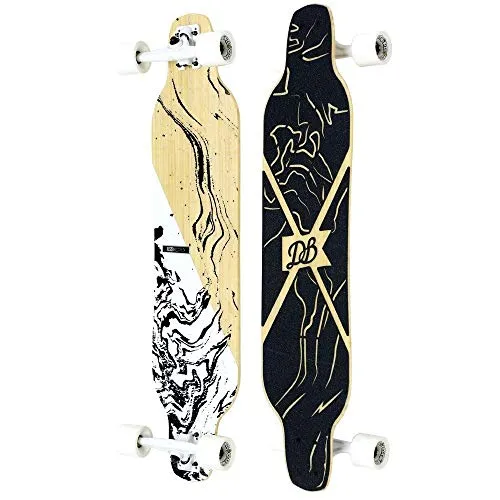
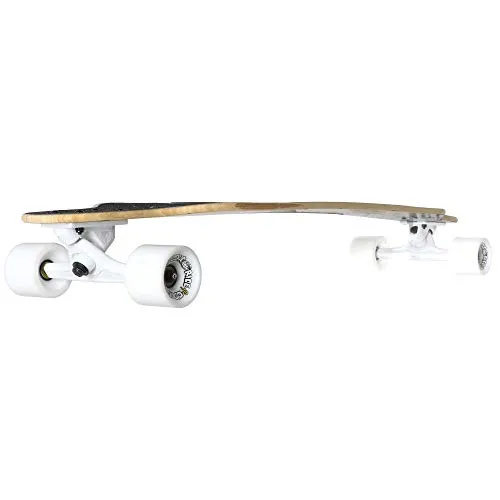
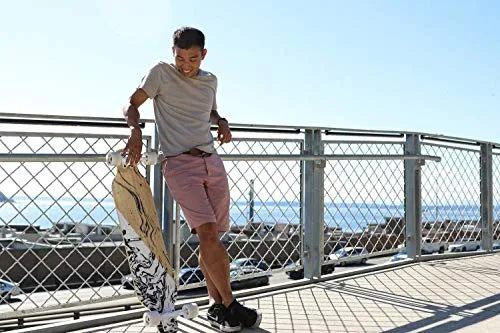

In [4]:
# Let's see what products we're working with
products.select(
    products.Product_Name,
    products.Image,
    products.Selling_Price,
    products.About_Product
).head(3)

## Add Semantic Search with Voyage AI Embeddings

We'll add an **embedding index** that converts product descriptions into vectors — enabling semantic search.

> **Key insight:** We set `input_type='document'` because we're embedding product data that users will search through. When someone searches, Pixeltable uses the same embedding function to convert their query into a vector — that way both products and searches live in the same vector space.

In [6]:
embed_fn = voyageai.embeddings.using(model='voyage-3.5', input_type='document')

In [ ]:
# Compute embeddings for all rows
products.add_embedding_index(
    idx_name='prod_idx',
    column=products.About_Product, 
    embedding=embed_fn,
    if_exists='replace'  # This will rebuild the index
)

In [8]:
products

table 'ecommerce_search/products'

    Column Name    Type Computed With
        Uniq_Id  String              
   Product_Name  String              
       Category  String              
  Selling_Price  String              
  About_Product  String              
          Image   Image              
      image_idx     Int              

 Index Name         Column  Metric                                          Embedding
   prod_idx  About_Product  cosine  embeddings(About_Product, model='voyage-3.5', ...

## Searching for items

In [9]:
# Find the dinosaur product directly and check its similarity score
query = 'realistic dinosaur figure'
sim = products.About_Product.similarity(string=query, idx='prod_idx')

products.where(products.Product_Name.contains('Dino')).select(
    products.Product_Name,
    products.About_Product,
    similarity=sim
).limit(3).collect()


Product_Name,About_Product,similarity
"Terra by Battat – 4 Dinosaur Toys, Medium – Dinosaurs for Kids & Collectors, Scientifically Accurate & Designed by A Paleo-Artist; Age 3+ (4 Pc)","Make sure this fits by entering your model number. | 4 medium-sized dinosaurs for kids, with lifelike pose, accurate ratio, and exquisitely detailed paint | Includes: Parasaurolophus walkeri, Stegosaurus ungulatus, Pachyrhinosaurus, and euoplocephalus tutus toy dinos | Museum Quality: classic toy dinosaurs designed by an internationally renowned paleo-artist | Educational toy: dinosaur toys for kids spark curiosity about paleontology, science, and natural History | Dimensions: Dimensions: miniature figurines measure 6.25-8.5 (L) 1.5-2.25 (W) 2.25-3.5 (H) inches approximately toys 6.25-8.5 (L) 1.5-2.25 (W) 2.25-3.5 (H) inches approximately | No batteries required, just imagination! | Earth-friendly recyclable packaging | Age: suggested for ages 3+ | Collect them all! Discover the entire Terra by Battat family of animal toy figurines and dinosaur playsets!",None
"Terra by Battat – 4 Dinosaur Toys, Medium – Dinosaurs for Kids & Collectors, Scientifically Accurate & Designed by A Paleo-Artist; Age 3+ (4 Pc)","Make sure this fits by entering your model number. | 4 medium-sized dinosaurs for kids, with lifelike pose, accurate ratio, and exquisitely detailed paint | Includes: Parasaurolophus walkeri, Stegosaurus ungulatus, Pachyrhinosaurus, and euoplocephalus tutus toy dinos | Museum Quality: classic toy dinosaurs designed by an internationally renowned paleo-artist | Educational toy: dinosaur toys for kids spark curiosity about paleontology, science, and natural History | Dimensions: Dimensions: miniature figurines measure 6.25-8.5 (L) 1.5-2.25 (W) 2.25-3.5 (H) inches approximately toys 6.25-8.5 (L) 1.5-2.25 (W) 2.25-3.5 (H) inches approximately | No batteries required, just imagination! | Earth-friendly recyclable packaging | Age: suggested for ages 3+ | Collect them all! Discover the entire Terra by Battat family of animal toy figurines and dinosaur playsets!",None
"Terra by Battat – 4 Dinosaur Toys, Medium – Dinosaurs for Kids & Collectors, Scientifically Accurate & Designed by A Paleo-Artist; Age 3+ (4 Pc)","Make sure this fits by entering your model number. | 4 medium-sized dinosaurs for kids, with lifelike pose, accurate ratio, and exquisitely detailed paint | Includes: Parasaurolophus walkeri, Stegosaurus ungulatus, Pachyrhinosaurus, and euoplocephalus tutus toy dinos | Museum Quality: classic toy dinosaurs designed by an internationally renowned paleo-artist | Educational toy: dinosaur toys for kids spark curiosity about paleontology, science, and natural History | Dimensions: Dimensions: miniature figurines measure 6.25-8.5 (L) 1.5-2.25 (W) 2.25-3.5 (H) inches approximately toys 6.25-8.5 (L) 1.5-2.25 (W) 2.25-3.5 (H) inches approximately | No batteries required, just imagination! | Earth-friendly recyclable packaging | Age: suggested for ages 3+ | Collect them all! Discover the entire Terra by Battat family of animal toy figurines and dinosaur playsets!",None


In [10]:
# Just get raw similarity values for first 10 rows
products.limit(10).select(
    products.Product_Name,
    similarity=sim
).collect()

Product_Name,similarity
"Disney Rapunzel Acrylic Key Ring, Multicolor",0.708
Lippert Components 287298 500:1 Motor - High Torque,0.629
"Weiler 14506 Nylox Cup Brush, 6"", 0.40/80SC Crimped Fill, 5/8""-11 UNC Nut",NaN
"DC Lantern 2.75"" PVC Figure, Green",NaN
"Aurora World Plush Graduation Bear, White Cap, 8.5""",0.711
Creativity for Kids Clay Keychains,0.707
Huffy Kids Bikes 16 & 20 inch with Streamers and BMX Pegs,NaN
Huffy Kids Bikes 16 & 20 inch with Streamers and BMX Pegs,NaN
Disney Mickey Golf Ball Spinner Pewter Key Ring Key Accessory,NaN
Disney Mickey Golf Ball Spinner Pewter Key Ring Key Accessory,NaN


In [11]:
# Let's see what scores the dinosaur products actually get
query = 'realistic dinosaur figure'
sim = products.About_Product.similarity(string=query, idx='prod_idx')

# Show top 10 with their scores
products.order_by(sim, asc=False).limit(10).select(
    products.Product_Name,
    products.About_Product,
    similarity=sim
).collect()


Product_Name,About_Product,similarity
Marvel Hulk Fist Pewter Key Ring,Made of pewter | Opp bag with backer card packaging | Highly detailed,0.759
Hansa Ostrich Baby Plush,"Make sure this fits by entering your model number. | True to life realism | Animals that teach tagging | Individually hand crafted | Custom designed, heirloom quality fabrics and accessories",0.757
Hansa Ostrich Baby Plush,"Make sure this fits by entering your model number. | True to life realism | Animals that teach tagging | Individually hand crafted | Custom designed, heirloom quality fabrics and accessories",0.757
Hansa Ostrich Baby Plush,"Make sure this fits by entering your model number. | True to life realism | Animals that teach tagging | Individually hand crafted | Custom designed, heirloom quality fabrics and accessories",0.757
Hansa Ostrich Baby Plush,"Make sure this fits by entering your model number. | True to life realism | Animals that teach tagging | Individually hand crafted | Custom designed, heirloom quality fabrics and accessories",0.757
Hansa Ostrich Baby Plush,"Make sure this fits by entering your model number. | True to life realism | Animals that teach tagging | Individually hand crafted | Custom designed, heirloom quality fabrics and accessories",0.757
Hansa Ostrich Baby Plush,"Make sure this fits by entering your model number. | True to life realism | Animals that teach tagging | Individually hand crafted | Custom designed, heirloom quality fabrics and accessories",0.757
Hansa Ostrich Baby Plush,"Make sure this fits by entering your model number. | True to life realism | Animals that teach tagging | Individually hand crafted | Custom designed, heirloom quality fabrics and accessories",0.757
The Corps Special Forces Action Figures & Vehicle Deluxe Playset (Packaging & Colors May Vary),"Make sure this fits by entering your model number. | Set includes 10 figures, assorted weapons, three vehicles; ages 3 and up | Highly detailed realistic figures are fully poseable with 15 points of articulation | Wearable and holdable weapons",0.734
The Corps Special Forces Action Figures & Vehicle Deluxe Playset (Packaging & Colors May Vary),"Make sure this fits by entering your model number. | Set includes 10 figures, assorted weapons, three vehicles; ages 3 and up | Highly detailed realistic figures are fully poseable with 15 points of articulation | Wearable and holdable weapons",0.734


## Making Search Reusable with Query Functions

That was great for a one-off search. But what if we want to make this reusable and automatic?

**Query functions** (`@pxt.query`) let you wrap search logic into a reusable function that can be used as a computed column.

In [12]:
# Semantic search on product descriptions with similarity threshold
# Note: We fetch extra results (limit * 5) to have enough after deduplication
# (Each product may have multiple rows due to multiple images)
@pxt.query
def search_products(query_text: str, limit: int = 5):
    """Search products by semantic similarity on product description.
    Filters results to only include products with similarity > 0.5.
    Returns more candidates to allow for deduplication."""
    sim = products['About_Product'].similarity(string=query_text)
    return (
        products
        .where(sim > 0.5)  # Filter by similarity threshold
        .order_by(sim, asc=False)
        .limit(limit * 5)  # Fetch extra to account for duplicates
        .select(
            products['Uniq_Id'],
            products['Product_Name'],
            products['Category'],
            products['Selling_Price'],
            products['About_Product'],
            score=sim
        )
    )

### Declarative Search with Computed Columns

The real power of `@pxt.query` functions is using them as **computed columns**. Create a searches table where results are computed automatically when queries are inserted:


In [13]:
# Create a searches table with semantic search as a computed column
searches = pxt.create_table(
    'ecommerce_search.searches',
    {'query': pxt.String}
)

# Search results computed automatically on insert
searches.add_computed_column(
    results=search_products(searches.query),
    if_exists='replace'  # Allow re-running to update column definition
)


Created table 'searches'.
Added 0 column values with 0 errors in 0.01 s


No rows affected.

In [14]:
searches

table 'ecommerce_search/searches'

 Column Name    Type           Computed With
       query  String                        
     results    Json  search_products(query)

In [15]:
searches.count()

0

In [16]:
# Insert a query - results computed automatically!
searches.insert([{'query': 'realistic dinosaur figure'}])

Inserted 1 row with 0 errors in 0.43 s (2.32 rows/s)


1 row inserted.

In [17]:
searches.collect()

query  \
0  realistic dinosaur figure   

                                             results  
0  [{'score': 0.7585492001440802, 'Uniq_Id': '940...

## Boost Relevance with Voyage AI Reranking

While semantic search is powerful, we can further improve result quality using Voyage AI's **rerank-2.5** model. The two-stage retrieval pattern:

1. **First stage**: Use embeddings to quickly retrieve candidates (top 15)
2. **Second stage**: Use the reranker to precisely score and reorder results

Let's add reranking as another computed column to our searches table:

In [18]:
# Helper UDFs for formatting results
@pxt.udf
def format_results(results: list[dict], limit: int = 5) -> list[str]:
    """Deduplicate by product ID and format for display."""
    if not results:
        return []
    seen_ids = set()
    unique = []
    for r in results:
        pid = r.get('Uniq_Id')
        if pid not in seen_ids:
            seen_ids.add(pid)
            unique.append(r)
            if len(unique) >= limit:
                break
    return [f"{r.get('Product_Name', 'N/A')[:50]}... ({r.get('Selling_Price', 'N/A')})" for r in unique]

@pxt.udf
def extract_descriptions(results: list[dict], limit: int = 15) -> list[str]:
    """Extract unique product descriptions for reranking."""
    if not results:
        return []
    seen_ids = set()
    descriptions = []
    for r in results:
        pid = r.get('Uniq_Id')
        desc = r.get('About_Product', '')
        if pid not in seen_ids and desc:
            seen_ids.add(pid)
            descriptions.append(desc)
            if len(descriptions) >= limit:
                break
    return descriptions

# Get more candidates for reranking
searches.add_computed_column(
    candidates=search_products(searches.query, limit=15),
    if_exists='replace'
)

# Add reranking using Voyage AI's rerank-2.5 model
searches.add_computed_column(
    reranked=voyageai.rerank(
        searches.query,
        extract_descriptions(searches.candidates),
        model='rerank-2.5',
        top_k=5
    ),
    if_exists='replace'
)

Added 1 column value with 0 errors in 0.44 s (2.25 rows/s)
Added 1 column value with 0 errors in 0.19 s (5.36 rows/s)


1 row updated.

In [19]:
# View the searches table structure
# Each query gets: results + candidates + reranked
searches

table 'ecommerce_search/searches'

 Column Name    Type                                      Computed With
       query  String                                                   
     results    Json                             search_products(query)
  candidates    Json                   search_products(query, limit=15)
    reranked    Json  rerank(query, extract_descriptions(candidates)...

In [20]:
# The query we inserted earlier now has reranked results too!
# View raw results to see the full structure
searches.select(
    searches.query,
    searches.results,
    searches.reranked
).collect()

query  \
0  realistic dinosaur figure   

                                             results  \
0  [{'score': 0.7585492001440802, 'Uniq_Id': '940...   

                                            reranked  
0  {'results': [{'index': 2, 'document': 'Make su...

In [21]:
# Insert another query to see the full pipeline in action
searches.insert([{'query': 'toys for kids who love dinosaurs and math'}])

Inserted 1 row with 0 errors in 0.71 s (1.41 rows/s)


1 row inserted.

In [22]:
searches.tail(1)

query  \
0  toys for kids who love dinosaurs and math   

                                             results  \
0  [{'score': 0.8211883100754095, 'Uniq_Id': '5ef...   

                                          candidates  \
0  [{'score': 0.8211883100754095, 'Uniq_Id': '5ef...   

                                            reranked  
0  {'results': [{'index': 0, 'document': 'Make su...

### Compare Embedding Search vs. Reranked Results

The reranker often surfaces more relevant results by considering the full query-document relationship:


In [56]:
# UDF to map reranked results back to product names
# The reranker returns document text, but we need product names for display
@pxt.udf
def format_reranked_with_names(candidates: list[dict], reranked: dict) -> list[str]:
    """Map reranked results back to product names using the candidates list."""
    if not reranked or 'results' not in reranked or not candidates:
        return []

    # Build a lookup from About_Product text to product info
    # (deduplicated by product ID)
    desc_to_product = {}
    seen_ids = set()
    for c in candidates:
        pid = c.get('Uniq_Id')
        if pid not in seen_ids:
            seen_ids.add(pid)
            desc = c.get('About_Product', '')
            desc_to_product[desc] = {
                'name': c.get('Product_Name', 'Unknown'),
                'price': c.get('Selling_Price', 'N/A')
            }

    # Map reranked documents back to product names
    results = []
    for r in reranked['results']:
        doc = r.get('document', '')
        score = r.get('relevance_score', 0)
        if doc in desc_to_product:
            p = desc_to_product[doc]
            results.append(f"{p['name'][:50]}... ({p['price']}) [score: {score:.2f}]")
        else:
            results.append(f"Unknown product [score: {score:.2f}]")
    return results

# Compare: embedding search vs reranked - now both show PRODUCT NAMES!
searches.select(
    searches.query,
    embedding_top_5=format_results(searches.results),
    reranked_top_5=format_reranked_with_names(searches.candidates, searches.reranked),
).collect()

query,embedding_top_5,reranked_top_5
gift for a kid who loves prehistoric animals,"[""Wild Republic Horse Plush, Stuffed Animal, Plush T... (\$16.22)"", ""Steiff Harry Potter Plush Keychain... (\$38.74)"", ""Learning Resources Dino Math Tracks Game, Place Va... (\$17.49)"", ""Strawberry Shortcake Classic Doll, 6\""... (\$12.89)"", ""Originals Aquaman DC Comics Superman Zombie String... (\$8.46)""]","[""Learning Resources Dino Math Tracks Game, Place Va... (\$17.49) [score: 0.61]"", ""Steiff Harry Potter Plush Keychain... (\$38.74) [score: 0.50]"", ""Wild Republic Great White Shark Plush Stuffed Anim... (\$14.99) [score: 0.49]"", ""Wild Republic Horse Plush, Stuffed Animal, Plush T... (\$16.22) [score: 0.46]"", ""Smart Play Ingenio Colors & Shapes Memory Match Ga... (\$15.20) [score: 0.38]""]"
toys for kids who love dinosaurs and math,"[""Learning Resources Dino Math Tracks Game, Place Va... (\$17.49)"", ""Odyssey Toys Hape Chunky Number Puzzle (10 Pieces)... (\$19.63)"", ""Smart Play Ingenio Colors & Shapes Memory Match Ga... (\$15.20)"", ""TOMY John Deere Learn 'n Pop Farmyard Friends Toy... (\$14.99)"", ""Hohner Kids MP383 Musical Shapes, 20 Piece, 3 Uniq... (\$65.89)""]","[""Learning Resources Dino Math Tracks Game, Place Va... (\$17.49) [score: 0.88]"", ""BathBlocks STEM Floating Construction Set... (\$24.99) [score: 0.50]"", ""Odyssey Toys Hape Chunky Number Puzzle (10 Pieces)... (\$19.63) [score: 0.46]"", ""Hohner Kids MP383 Musical Shapes, 20 Piece, 3 Uniq... (\$65.89) [score: 0.42]"", ""Smart Play Ingenio Colors & Shapes Memory Match Ga... (\$15.20) [score: 0.41]""]"


Product_Name,Image,Selling_Price,similarity
"Learning Resources Dino Math Tracks Game, Place Value, Counting, Addition and Subtraction Dinosaur Game, Ages 6+",,\$17.49,0.821
"Learning Resources Dino Math Tracks Game, Place Value, Counting, Addition and Subtraction Dinosaur Game, Ages 6+",,\$17.49,0.821
"Learning Resources Dino Math Tracks Game, Place Value, Counting, Addition and Subtraction Dinosaur Game, Ages 6+",,\$17.49,0.821
"Learning Resources Dino Math Tracks Game, Place Value, Counting, Addition and Subtraction Dinosaur Game, Ages 6+",,\$17.49,0.821
"Learning Resources Dino Math Tracks Game, Place Value, Counting, Addition and Subtraction Dinosaur Game, Ages 6+",,\$17.49,0.821

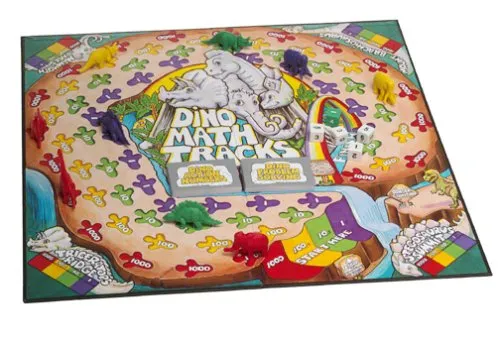
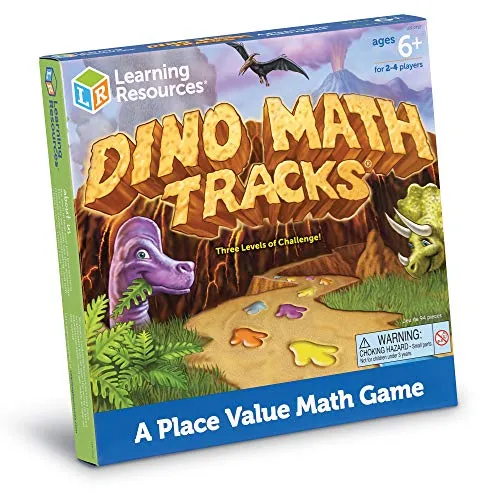
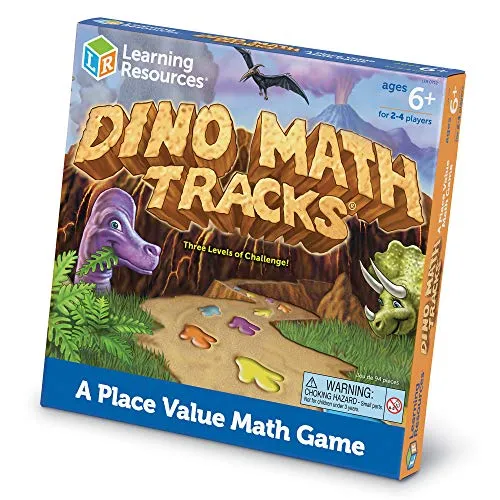
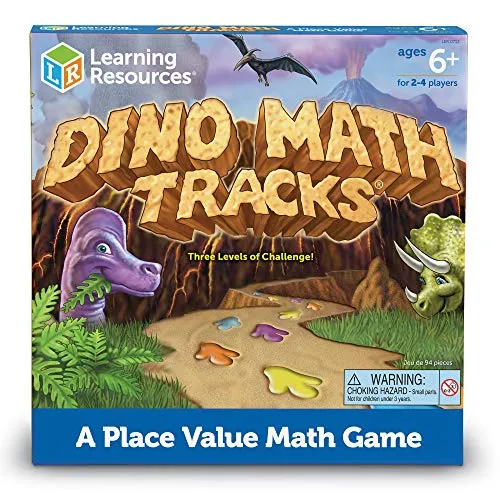
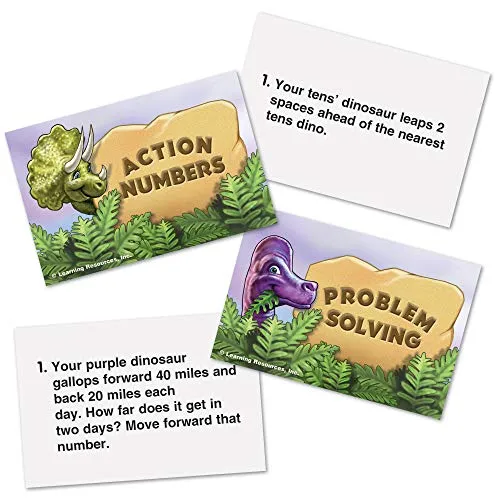

In [24]:
# 📊 EMBEDDING SEARCH RESULTS - with images!
query = 'toys for kids who love dinosaurs and math'
sim = products.About_Product.similarity(string=query)

products.order_by(sim, asc=False).limit(5).select(
    products.Product_Name,
    products.Image,
    products.Selling_Price,
    similarity=sim
).collect()

## Incremental Updates: Adding New Products

One of Pixeltable's key strengths is handling incremental updates. When new products are added to the catalog, embeddings are computed automatically—no need to reprocess the entire dataset.


In [25]:
# Add new products - embeddings for all three indexes are computed automatically!
new_products = [
    {
        'Uniq_Id': 'new_001',
        'Product_Name': 'Ultimate STEM Building Kit - 500 Pieces',
        'Category': 'Toys & Games | Building Toys | Building Sets',
        'About_Product': 'Educational building set with 500 pieces for ages 6+. Includes gears, motors, and instruction booklet for 50 projects. Develops problem-solving and engineering skills.',
        'Selling_Price': '$49.99',
        'Image': None,  # Use None for no image, not empty string
        'image_idx': 0
    },
    {
        'Uniq_Id': 'new_002', 
        'Product_Name': 'Outdoor Adventure Binoculars for Kids',
        'Category': 'Toys & Games | Sports & Outdoor Play | Exploration Toys',
        'About_Product': 'Kid-friendly binoculars with 8x magnification, rubber grip, and neck strap. Perfect for bird watching, camping, and nature exploration. Shockproof design.',
        'Selling_Price': '$24.99',
        'Image': None,  # Use None for no image, not empty string
        'image_idx': 0
    }
]

products.insert(new_products)


Inserted 2 rows with 0 errors in 0.21 s (9.66 rows/s)


2 rows inserted.

---

## 🎁 Bonus: Agentic Search (if time permits)

Now let's combine everything into an **agentic pipeline** where an LLM decides which tools to use. This section is optional but shows the full power of Pixeltable's declarative approach.

In [45]:
# Create an exact product lookup using retrieval_udf
# This queries by product ID for precise lookups
get_product_by_id = pxt.retrieval_udf(
    products,
    name='get_product_by_id',
    description='Look up a specific product by its unique ID (Uniq_Id)',
    parameters=['Uniq_Id'],
    limit=1
)

In [ ]:
# Add Voyage AI multimodal embedding index on the Image column
# voyage-multimodal-3 embeds both text AND images in the same space!
products.add_embedding_index(
    'Image',
    embedding=voyageai.multimodal_embed.using(model='voyage-multimodal-3', input_type='document'),
    if_exists='ignore'
)

In [ ]:
# Lightweight agent search functions - return MINIMAL data to avoid context overflow
# (Full search_products is defined above but returns too much data for LLM context)
@pxt.query
def agent_search(query_text: str, limit: int = 5):
    """Lightweight product search for agent - returns only essential fields."""
    sim = products['About_Product'].similarity(string=query_text)
    return (
        products
        .where(sim > 0.5)
        .order_by(sim, asc=False)
        .limit(limit * 5)  # Extra for deduplication
        .select(
            products['Uniq_Id'],
            products['Product_Name'],
            products['Selling_Price'],
            # Short description only - first 100 chars
        )
    )

@pxt.query
def agent_image_search(query_text: str, limit: int = 3):
    """Lightweight image search for agent - returns product info without base64."""
    sim = products.Image.similarity(string=query_text)
    return (
        products
        .where(sim > 0.3)
        .order_by(sim, asc=False)
        .limit(limit)
        .select(
            products.Uniq_Id,
            products.Product_Name,
            products.Selling_Price,
            # No base64 images here - too large for LLM context
        )
    )

In [38]:
# Create a product lookup by ID (returns all columns for matching product)
get_product_summary = pxt.retrieval_udf(
    products,
    name='get_product_summary',
    description='Look up a specific product by its unique ID (Uniq_Id)',
    parameters=['Uniq_Id'],
    limit=1
)

In [39]:
# Bundle lightweight tools for LLM use (minimal data to avoid context overflow)
product_tools = pxt.tools(
    agent_search,           # Lightweight semantic search (name, price only)
    agent_image_search,     # Lightweight image search (no base64)
    get_product_summary     # Lightweight lookup (essential fields only)
)

In [40]:
# Set up OpenAI for the agent (or use Anthropic, etc.)
if 'OPENAI_API_KEY' not in os.environ:
    os.environ['OPENAI_API_KEY'] = getpass.getpass('Enter your OpenAI API key: ')

from pixeltable.functions import openai

In [41]:
# Create the agent table with tool-calling pipeline
agent = pxt.create_table(
    'ecommerce_search.agent',
    {'question': pxt.String}
)

# System prompt for the product assistant (using lightweight tool names)
SYSTEM_PROMPT = """You are a helpful e-commerce product assistant. You have access to three tools:
1. agent_search: Find products by semantic search on descriptions
2. agent_image_search: Find products visually - use when user asks to "show" products
3. get_product_summary: Look up a specific product by ID

Be concise and helpful. Summarize product results clearly."""

# LLM decides which tools to call
agent.add_computed_column(
    llm_response=openai.chat_completions(
        messages=[
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': agent.question}
        ],
        model='gpt-4o-mini',
        tools=product_tools
    )
)

# Automatically execute the tool calls
agent.add_computed_column(
    tool_results=openai.invoke_tools(product_tools, agent.llm_response)
)

Created table 'agent'.
Added 0 column values with 0 errors in 0.00 s
Added 0 column values with 0 errors in 0.01 s


No rows affected.

In [42]:
# UDF to format tool results concisely for LLM (avoid context overflow)
@pxt.udf
def assemble_answer_prompt(question: str, tool_results: dict) -> list[dict]:
    """Format tool results concisely for the LLM to generate an answer."""
    results_text = []
    for tool_name, outputs in (tool_results or {}).items():
        if outputs is None:
            continue
        # Deduplicate by product ID
        seen_ids = set()
        for output in outputs:
            if output is None:
                continue
            if isinstance(output, dict):
                pid = output.get('Uniq_Id', '')
                if pid in seen_ids:
                    continue
                seen_ids.add(pid)
                name = output.get('Product_Name', 'Unknown')
                price = output.get('Selling_Price', 'N/A')
                results_text.append(f"• {name} - {price}")
    
    context = "\n".join(results_text[:10]) if results_text else "No results found."
    
    return [
        {'role': 'system', 'content': 'You are a helpful product assistant. Summarize the search results concisely.'},
        {'role': 'user', 'content': f"Question: {question}\n\nProducts Found:\n{context}\n\nProvide a brief, helpful response."}
    ]

# Generate final answer using tool results
agent.add_computed_column(
    answer_prompt=assemble_answer_prompt(agent.question, agent.tool_results)
)

agent.add_computed_column(
    answer=openai.chat_completions(
        messages=agent.answer_prompt,
        model='gpt-4o-mini'
    )['choices'][0]['message']['content']
)

Added 0 column values with 0 errors in 0.01 s
Added 0 column values with 0 errors in 0.01 s


No rows affected.

In [43]:
# Test the agent with different questions
test_questions = [
    {'question': 'What educational toys do you have for kids who like building?'},
    {'question': 'Find me colorful toys for toddlers'},
    {'question': 'Tell me about product new_001'},
]

agent.insert(test_questions)

Inserted 3 rows with 0 errors in 5.70 s (0.53 rows/s)


3 rows inserted.

In [44]:
# View the agent's answers
agent.select(agent.question, agent.answer).collect()

question,answer
Tell me about product new_001,"It seems that there are no search results available for the product ""new_001."" If you can provide more details or clarify the product name, I can assist you further."
What educational toys do you have for kids who like building?,"It seems that there are currently no specific educational toys listed for kids who enjoy building. However, popular options typically include building blocks, construction sets, LEGO kits, and magnetic tiles. These types of toys encourage creativity, problem-solving, and fine motor skills. You might want to explore local toy stores or online retailers for a variety of building toys."
Find me colorful toys for toddlers,"I couldn't find specific colorful toys for toddlers, but you can try searching on popular online retailers or local stores specializing in children's toys. Look for categories like building blocks, stuffed animals, or activity sets, which often feature vibrant colors and are suitable for young children."


In [45]:
# See the full pipeline: question → tool results → answer
agent.select(
    agent.question,
    agent.tool_results,
    agent.answer
).collect()

question,tool_results,answer
Tell me about product new_001,"{""agent_search"": null, ""agent_image_search"": null, ""get_product_summary"": [[{""Image"": null, ""Uniq_Id"": ""new_001"", ""Category"": ""Toys & Games | Building Toys | Building Sets"", ""image_idx"": 0, ""Product_Name"": ""Ultimate STEM Building Kit - 500 Pieces"", ""About_Product"": ""Educational building set with 500 pieces for ages 6+. Includes gears, motors, and instruction booklet for 50 projects. Develops problem-solving and engineering skills."", ""Selling_Price"": ""\$49.99""}]]}","It seems that there are no search results available for the product ""new_001."" If you can provide more details or clarify the product name, I can assist you further."
What educational toys do you have for kids who like building?,"{""agent_search"": [[{""Uniq_Id"": ""new_001"", ""Product_Name"": ""Ultimate STEM Building Kit - 500 Pieces"", ""Selling_Price"": ""\$49.99""}, {""Uniq_Id"": ""2b47bdb56e45a2bcd883dda0ac5c396e"", ""Product_Name"": ""Creativity for Kids Clay Keychains"", ""Selling_Price"": ""\$6.99""}, {""Uniq_Id"": ""2b47bdb56e45a2bcd883dda0ac5c396e"", ""Product_Name"": ""Creativity for Kids Clay Keychains"", ""Selling_Price"": ""\$6.99""}, {""Uniq_Id"": ""2b47bdb56e45a2bcd883dda0ac5c396e"", ""Product_Name"": ""Creativity for Kids Clay Keychains"", ""Selling_Price"": ""\$6.99""}, {""Uniq_Id"": ""2b47bdb56e45a2bcd883dda0ac5c396e"", ""Product_Name"": ""Creativity for Kids Clay Keychains"", ""Selling_Price"": ""\$6.99""}, {""Uniq_Id"": ""ca60bfaf525369543188f03b98d5d75e"", ""Product_Name"": ""BathBlocks STEM Floating Construction Set"", ""Selling_Price"": ""\$24.99""}, ..., {""Uniq_Id"": ""031e2e0c145b46ff6ed4fbded1e837c5"", ""Product_Name"": ""Odyssey Toys Hape Chunky Number Puzzle (10 Pieces), Multicolor, 5'' x 2''"", ""Selling_Price"": ""\$19.63""}, {""Uniq_Id"": ""3a165de98664f7a9c26cec87cf690473"", ""Product_Name"": ""Constructive Playthings Tree Blocks, Set of 36 Hand-Cut Wood Pieces, Various Shapes and Shades, STEM Approved"", ""Selling_Price"": ""\$64.94""}, {""Uniq_Id"": ""3a165de98664f7a9c26cec87cf690473"", ""Product_Name"": ""Constructive Playthings Tree Blocks, Set of 36 Hand-Cut Wood Pieces, Various Shapes and Shades, STEM Approved"", ""Selling_Price"": ""\$64.94""}, {""Uniq_Id"": ""443dffffe6264a6f2ca54a5e8084d775"", ""Product_Name"": ""Smart Play Ingenio Colors & Shapes Memory Match Game"", ""Selling_Price"": ""\$15.20""}, {""Uniq_Id"": ""443dffffe6264a6f2ca54a5e8084d775"", ""Product_Name"": ""Smart Play Ingenio Colors & Shapes Memory Match Game"", ""Selling_Price"": ""\$15.20""}, {""Uniq_Id"": ""89354e527633105bd209522dcd6f0260"", ""Product_Name"": ""Silver Unicorn"", ""Selling_Price"": ""\$10.64""}]], ""agent_image_search"": null, ""get_product_summary"": null}","It seems that there are currently no specific educational toys listed for kids who enjoy building. However, popular options typically include building blocks, construction sets, LEGO kits, and magnetic tiles. These types of toys encourage creativity, problem-solving, and fine motor skills. You might want to explore local toy stores or online retailers for a variety of building toys."
Find me colorful toys for toddlers,"{""agent_search"": [[{""Uniq_Id"": ""3cb8cc66556c1b240fcdfdc9b89db022"", ""Product_Name"": ""Bright Starts Rattle & Shake Barbell Toy, Ages 3 months +"", ""Selling_Price"": ""\$2.88""}, {""Uniq_Id"": ""3cb8cc66556c1b240fcdfdc9b89db022"", ""Product_Name"": ""Bright Starts Rattle & Shake Barbell Toy, Ages 3 months +"", ""Selling_Price"": ""\$2.88""}, {""Uniq_Id"": ""2b47bdb56e45a2bcd883dda0ac5c396e"", ""Product_Name"": ""Creativity for Kids Clay Keychains"", ""Selling_Price"": ""\$6.99""}, {""Uniq_Id"": ""2b47bdb56e45a2bcd883dda0ac5c396e"", ""Product_Name"": ""Creativity for Kids Clay Keychains"", ""Selling_Price"": ""\$6.99""}, {""Uniq_Id"": ""2b47bdb56e45a2bcd883dda0ac5c396e"", ""Product_Name"": ""Creativity for Kids Clay Keychains"", ""Selling_Price"": ""\$6.99""}, {""Uniq_Id"":

In [46]:
# Display agent answers in a readable format
for row in agent.select(agent.question, agent.answer).collect():
    print(f"Q: {row['question']}")
    print(f"A: {row['answer']}\n")
    print("-" * 60 + "\n")

Q: Tell me about product new_001
A: It seems that there are no search results available for the product "new_001." If you can provide more details or clarify the product name, I can assist you further.

------------------------------------------------------------

Q: What educational toys do you have for kids who like building?
A: It seems that there are currently no specific educational toys listed for kids who enjoy building. However, popular options typically include building blocks, construction sets, LEGO kits, and magnetic tiles. These types of toys encourage creativity, problem-solving, and fine motor skills. You might want to explore local toy stores or online retailers for a variety of building toys.

------------------------------------------------------------

Q: Find me colorful toys for toddlers
A: I couldn't find specific colorful toys for toddlers, but you can try searching on popular online retailers or local stores specializing in children's toys. Look for categories l

## Summary

**What we built:**

1. **Semantic Search** — Voyage AI's `voyage-3.5` embeddings understand customer intent, not just keywords
2. **Neural Reranking** — `rerank-2.5` boosts the most relevant results to the top
3. **Declarative Pipelines** — Pixeltable computes results automatically when queries are inserted

**Key takeaways:**

- **One line** to add embedding search: `products.add_embedding_index('About_Product', embedding=embed_fn)`
- **Computed columns** run automatically — no batch jobs needed
- **Reranking** improves precision on top of fast embedding retrieval

**The Pixeltable difference:** Declare your pipeline once, and it runs forever — on new data, new queries, everything.

## Learn More

**Voyage AI Resources**
- [Voyage AI Documentation](https://docs.voyageai.com/)
- [Embedding Models](https://docs.voyageai.com/docs/embeddings) - voyage-3.5 and other models
- [Reranker Guide](https://docs.voyageai.com/docs/reranker) - rerank-2.5 and rerank-2.5-lite
- [Voyage AI + MongoDB](https://www.mongodb.com/blog/post/voyage-ai-joins-mongodb-to-advance-ai-powered-applications) - Voyage AI is now part of MongoDB

**Pixeltable Resources**
- [Documentation](https://docs.pixeltable.com/)
- [Embedding Indexes Guide](https://docs.pixeltable.com/platform/embedding-indexes)
- [Tool Calling with LLMs](https://docs.pixeltable.com/howto/cookbooks/agents/llm-tool-calling) - Agent patterns
- [Data Lookup UDFs](https://docs.pixeltable.com/howto/cookbooks/agents/pattern-data-lookup) - Retrieval UDFs

**Get Started**
- [Sign up for Voyage AI](https://www.voyageai.com/) (free tier available)
- [Install Pixeltable](https://github.com/pixeltable/pixeltable): `pip install pixeltable`